# Deep Q Networks

Code based on : RLDMUU, UniNE 2026, jakub.tluczek@unine.ch

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
from collections import deque
import random

In [2]:
torch.manual_seed(123)
device = torch.device(torch.accelerator.current_accelerator() if torch.accelerator.is_available() else 'cpu')
np.random.seed(123)

In [3]:
# running mean function for the purpose of visualization
def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, 0)) 
    return (cumsum[N:] - cumsum[:-N]) / float(N)

To make DQN work we have to define both the Q-network structure and a replay buffer, from which the transitions used to update the networks will be sampled:

In [4]:
class QNetwork(nn.Module):
    def __init__(self, n_states, n_actions, hidden_dim):
        super(QNetwork, self).__init__()
        self.linear1 = nn.Linear(n_states, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.linear3 = nn.Linear(hidden_dim, n_actions)

    def forward(self, state):
        x = F.relu(self.linear1(state))
        x = F.relu(self.linear2(x))
        return self.linear3(x)

In [5]:
class ReplayBuffer:
    def __init__(self, size):
        self.memory = deque([], maxlen=size)

    # this method samples transitions and returns tensors of each type registered in the environment step
    def sample(self, sample_size):
        sample = random.sample(self.memory, sample_size)
        states = []
        actions = []
        rewards = []
        next_states = []
        dones = []
        for x in sample:
            states.append(x[0])
            actions.append(x[1])
            rewards.append(x[2])
            next_states.append(x[3])
            dones.append(x[4])
        states = torch.tensor(states, dtype=torch.float32).to(device)
        actions = torch.tensor(actions).to(device)
        rewards = torch.tensor(rewards).to(device)
        next_states = torch.tensor(next_states, dtype=torch.float32).to(device)
        dones = torch.tensor(dones, dtype=torch.int).to(device)
        return states, actions, rewards, next_states, dones
    
    # add transition to the buffer
    def append(self, item):
        self.memory.append(item)

    def __len__(self):
        return len(self.memory)

In [6]:
def parameter_update(source_model, target_model, tau):
    for target_param, source_param in zip(target_model.parameters(), source_model.parameters()):
        target_param.data.copy_(tau * source_param.data + (1.0 - tau)*target_param.data)

# Training with sparse rewards

In [17]:
policy_network = QNetwork(n_states=11, n_actions=4, hidden_dim=128).to(device)
policy_optimizer = torch.optim.Adam(params=policy_network.parameters(), lr=5e-4)
target_network = QNetwork(n_states=11, n_actions=4, hidden_dim=128).to(device)

In [18]:
from game_env.snake_env import SnakeEnv

env = SnakeEnv(height=8, width=8)

Game without obstacles


In [20]:
NUM_TRAJECTORIES = 10_000
MAX_EPISODE_LENGTH = 500

gamma = 0.99
EPSILON = 0.05
SOFT_UPDATE = 0.01
BATCH_SIZE = 512
# warmup steps to collect the data first
WARMUP = 1000

# placeholders for rewards for each episode
cumulative_rewards = []
scores = []
policy_losses = []
# declaring the replay buffer
transition_buffer = ReplayBuffer(10000)
# iterating through trajectories
for tau in tqdm(range(NUM_TRAJECTORIES)):
    # resetting the environment
    state, info = env.reset(seed=123)
    # setting done to False for while loop 
    done = False
    cumul_r = 0
    t = 0
    score = 0
    while done == False and t < MAX_EPISODE_LENGTH:
      # retrieving Q(s, a) for all possible a
      if  np.random.random() < EPSILON:
        action = env.action_space.sample()
      else:
        with torch.no_grad():
          action_q_values = policy_network(torch.tensor(state, dtype=torch.float32).to(device))
        action = torch.argmax(action_q_values.flatten()).detach().cpu().numpy().item()
      
      # keeping track of previous state
      prev_state = state
      # environment step
      state, reward, done, truncation, info = env.step(action)

      transition_buffer.append((prev_state, action, reward, state, done))
      

      cumul_r += reward
      t += 1
      score = info["score"]

    # logging the episode length as a cumulative reward
    cumulative_rewards.append(cumul_r)
    scores.append(score)
    
    if len(transition_buffer) > WARMUP:
        states, actions, rewards, next_states, dones = transition_buffer.sample(sample_size=BATCH_SIZE)
        # getting the maximizing Q-value
        # max(x) return first x values ordered in a decreasing order
        q_target = target_network(torch.tensor(next_states, dtype=torch.float32).to(device)).detach().max(1)[0] # float for mps acceleration
        # using Q-values of target network only for non-terminal state
        expected_values = rewards + gamma * q_target*(torch.ones(BATCH_SIZE).to(device) - dones)
        # selecting Q-values of actions taken, using current policy network
        # gather() takes only values indicated by a given index, in this case, action taken
        output = policy_network(states).gather(1, actions.view(-1,1))
        # computing the loss between r + γ * max Q(s',a) and Q(s,a)
        loss = F.mse_loss(output.flatten(), expected_values)
        policy_losses.append(loss.item())
        policy_optimizer.zero_grad()
        loss.backward()
        policy_optimizer.step()
        # soft parameter update
        parameter_update(policy_network, target_network, SOFT_UPDATE)

torch.save(policy_network.state_dict(), "snake_dql_sparse_10k.pt")


  0%|          | 3/10000 [00:00<40:38,  4.10it/s]/var/folders/kv/b1gslbxj1sb_wvrlx344hk780000gn/T/ipykernel_42237/723041058.py:55: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  q_target = target_network(torch.tensor(next_states, dtype=torch.float32).to(device)).detach().max(1)[0] # float for mps acceleration
100%|██████████| 10000/10000 [13:11<00:00, 12.63it/s]


# Training with dense rewards

In [21]:
policy_network = QNetwork(n_states=11, n_actions=4, hidden_dim=128).to(device)
policy_optimizer = torch.optim.Adam(params=policy_network.parameters(), lr=5e-4)
target_network = QNetwork(n_states=11, n_actions=4, hidden_dim=128).to(device)

In [22]:
from game_env.snake_env import SnakeEnv

env = SnakeEnv(height=8, width=8, living_cost=True)

Game without obstacles


In [23]:
NUM_TRAJECTORIES = 10_000
MAX_EPISODE_LENGTH = 500

gamma = 0.99
EPSILON = 0.05
SOFT_UPDATE = 0.01
BATCH_SIZE = 512
# warmup steps to collect the data first
WARMUP = 1000

# placeholders for rewards for each episode
cumulative_rewards_dense = []
scores_dense = []
policy_losses_dense = []
# declaring the replay buffer
transition_buffer = ReplayBuffer(10000)
# iterating through trajectories
for tau in tqdm(range(NUM_TRAJECTORIES)):
    # resetting the environment
    state, info = env.reset(seed=123)
    # setting done to False for while loop 
    done = False
    cumul_r = 0
    t = 0
    score = 0
    while done == False and t < MAX_EPISODE_LENGTH:
        # retrieving Q(s, a) for all possible a
        action_q_values = policy_network(torch.tensor(state, dtype=torch.float32).to(device))
        # epsilon-greedy action
        action = np.random.choice(
            [torch.argmax(action_q_values.flatten()).detach().cpu().numpy(), 
             np.random.choice([0, 1, 2])], 
             p=[1-EPSILON, EPSILON])
        # keeping track of previous state
        prev_state = state
        # environment step
        state, reward, done, truncation, info = env.step(action)

        transition_buffer.append((prev_state, action, reward, state, done))
        

        cumul_r += reward
        t += 1
        score = info["score"]

    # logging the episode length as a cumulative reward
    cumulative_rewards_dense.append(cumul_r)
    scores_dense.append(score)
    if len(transition_buffer) > WARMUP:
        states, actions, rewards, next_states, dones = transition_buffer.sample(sample_size=BATCH_SIZE)
        # getting the maximizing Q-value
        # max(x) return first x values ordered in a decreasing order
        q_target = target_network(torch.tensor(next_states, dtype=torch.float32).to(device)).detach().max(1)[0] # float for mps acceleration
        # using Q-values of target network only for non-terminal state
        expected_values = rewards + gamma * q_target*(torch.ones(BATCH_SIZE).to(device) - dones)
        # selecting Q-values of actions taken, using current policy network
        # gather() takes only values indicated by a given index, in this case, action taken
        output = policy_network(states).gather(1, actions.view(-1,1))
        # computing the loss between r + γ * max Q(s',a) and Q(s,a)
        loss = F.mse_loss(output.flatten(), expected_values)
        policy_losses_dense.append(loss.item())
        policy_optimizer.zero_grad()
        loss.backward()
        policy_optimizer.step()
        # soft parameter update
        parameter_update(policy_network, target_network, SOFT_UPDATE)

torch.save(policy_network.state_dict(), "snake_dql_dense_10k.pt")


  2%|▏         | 246/10000 [00:00<00:37, 257.43it/s]/var/folders/kv/b1gslbxj1sb_wvrlx344hk780000gn/T/ipykernel_42237/3527900147.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  q_target = target_network(torch.tensor(next_states, dtype=torch.float32).to(device)).detach().max(1)[0] # float for mps acceleration
100%|██████████| 10000/10000 [10:10<00:00, 16.38it/s]


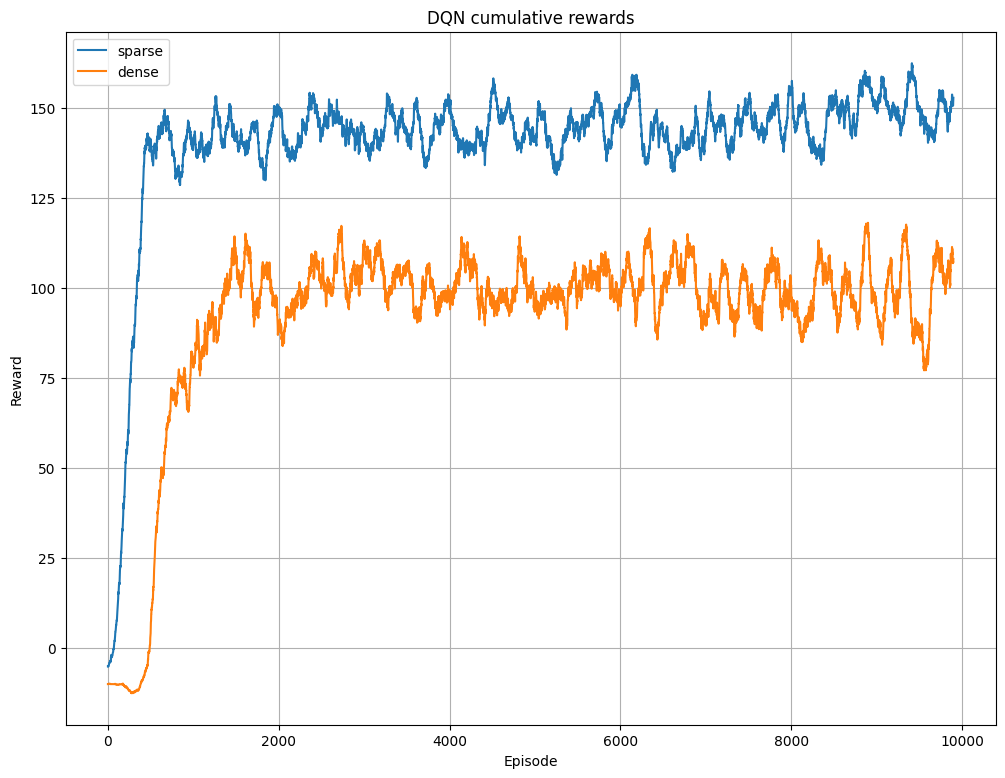

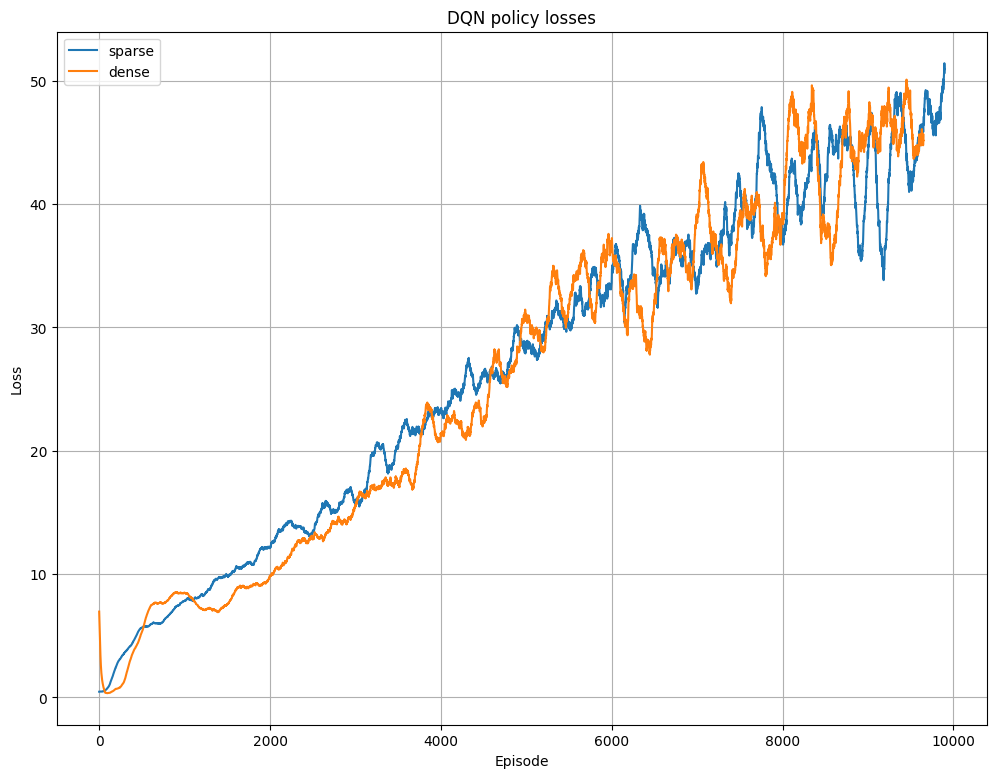

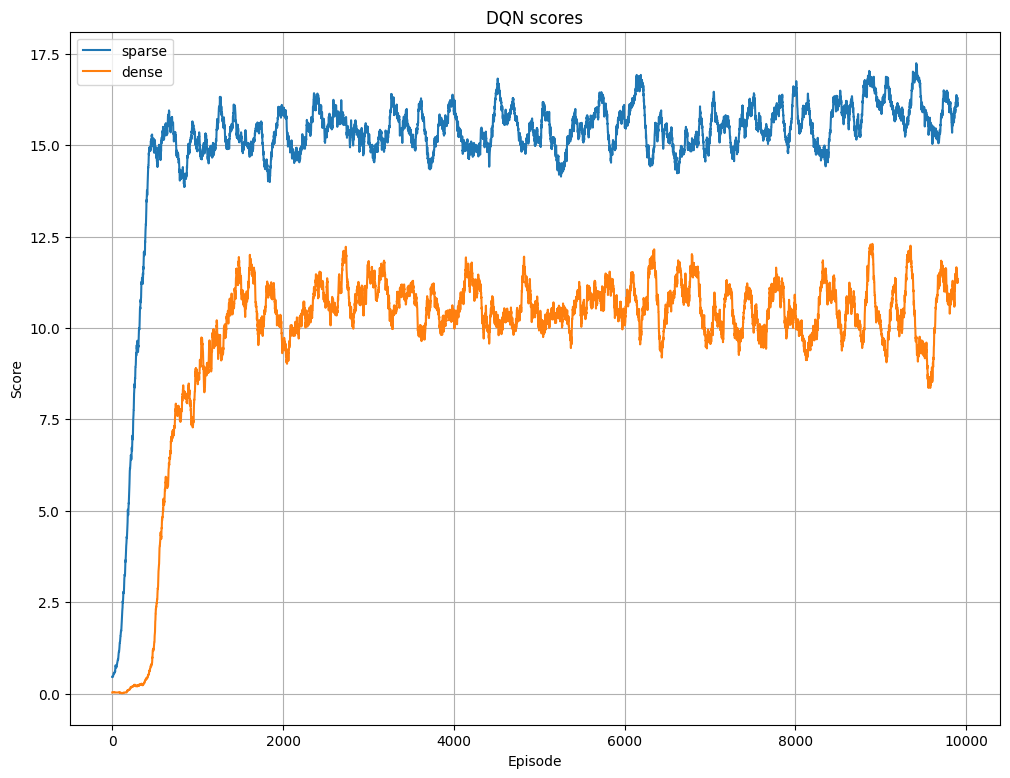

In [26]:
plt.figure(figsize=(12,9))
plt.plot(running_mean(cumulative_rewards, 100), label="sparse")
plt.plot(running_mean(cumulative_rewards_dense, 100), label="dense")
plt.title("DQN cumulative rewards")
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.grid()
plt.legend()
plt.figure(figsize=(12,9))
plt.plot(running_mean(policy_losses,100), label="sparse")
plt.plot(running_mean(policy_losses_dense,100), label="dense")
plt.title("DQN policy losses")
plt.xlabel('Episode')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.figure(figsize=(12,9))
plt.plot(running_mean(scores, 100), label="sparse")
plt.plot(running_mean(scores_dense, 100), label="dense")
plt.title("DQN scores")
plt.xlabel('Episode')
plt.ylabel('Score')
plt.grid()
plt.legend()
